# 🫀 Model Selection - Heart Disease Classification

- **Author**: Laura Granda
- **Date**: 2026-03-15
- **Input**: `data/03_primary/corazon_explored.parquet`
- **Output**: Best model ranked by Recall CV Mean

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

# Add project root to python path
sys.path.append(str(Path.cwd().resolve().parents[1]))
from src.model.evaluation import evaluate_classification_model
from src.pipelines.feature_pipeline.build_features import create_preprocessor

## 💾 Load data

In [2]:
DATA_PATH: Path = (
    Path.cwd().resolve().parents[1] / "data" / "03_primary" / "corazon_explored.parquet"
)
NUMERIC_FEATURES: list[str] = ["age", "max_hr", "old_peak"]
CATEGORICAL_FEATURES: list[str] = ["chest_pain", "sex"]
ORDINAL_FEATURES: list[str] = ["thal", "slope", "ca", "exang"]
FEATURES: list[str] = [*NUMERIC_FEATURES, *CATEGORICAL_FEATURES, *ORDINAL_FEATURES]
TARGET: str = "disease"
CATEGORICAL_ORDINAL: list[str] = [*CATEGORICAL_FEATURES, *ORDINAL_FEATURES]

df: pd.DataFrame = pd.read_parquet(DATA_PATH)
print(f"Shape before drop_duplicates: {df.shape}")
df = df.drop_duplicates()
print(f"Shape after drop_duplicates: {df.shape}")

# Select only preprocessor features + target
df = df[[*FEATURES, TARGET]]

# Convert categorical/ordinal columns to object dtype for sklearn compatibility
for col in CATEGORICAL_ORDINAL:
    df[col] = df[col].astype(str)

print(f"Final shape: {df.shape}")

Shape before drop_duplicates: (2919, 14)
Shape after drop_duplicates: (480, 14)
Final shape: (480, 10)


## ✂️ Train / Test split

In [3]:
X: pd.DataFrame = df[FEATURES]
y: pd.Series = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")

X_train: (384, 9) | X_test: (96, 9)
y_train: (384,) | y_test: (96,)


## 🤖 Instantiate Models

In [4]:
RANDOM_STATE: int = 42

models_to_test: dict = {
    "Logistic Regression": LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "SVC": SVC(probability=True, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
}

## 🏟️ Model Competition

In [5]:
RECALL_SORT_COL: str = "recall_cv_mean"

results: list[pd.DataFrame] = []

for name, model in models_to_test.items():
    print(f"Evaluating: {name}...")
    row: pd.DataFrame = evaluate_classification_model(
        model, create_preprocessor(), X_train, y_train
    )
    row["Model"] = name
    results.append(row)

summary: pd.DataFrame = (
    pd.concat(results, ignore_index=True)
    .set_index("Model")
    .sort_values(RECALL_SORT_COL, ascending=False)
)
summary

Evaluating: Logistic Regression...
Evaluating: Random Forest...
Evaluating: SVC...
Evaluating: Gradient Boosting...
Evaluating: KNN...


,accuracy_train_score,accuracy_cv_mean,accuracy_cv_std,f1_train_score,f1_cv_mean,f1_cv_std,precision_train_score,precision_cv_mean,precision_cv_std,recall_train_score,recall_cv_mean,recall_cv_std
Model,,,,,,,,,,,,
Random Forest,1.000000,0.836235,0.038932,1.000000,0.825313,0.046172,1.000000,0.840324,0.037854,1.000000,0.816374,0.085955
Gradient Boosting,0.977143,0.825843,0.046601,0.975956,0.814587,0.052210,0.984074,0.832788,0.060039,0.967999,0.804971,0.089313
Logistic Regression,0.820602,0.809919,0.040277,0.807672,0.794566,0.044202,0.830389,0.826100,0.066315,0.786229,0.772515,0.082556
KNN,0.798326,0.708637,0.074070,0.790230,0.687855,0.063160,0.787828,0.725068,0.100915,0.792888,0.668129,0.084221
SVC,0.649600,0.641026,0.065695,0.570665,0.552813,0.096544,0.691530,0.688626,0.106808,0.486086,0.473392,0.116758


## 📊 Visual Comparison

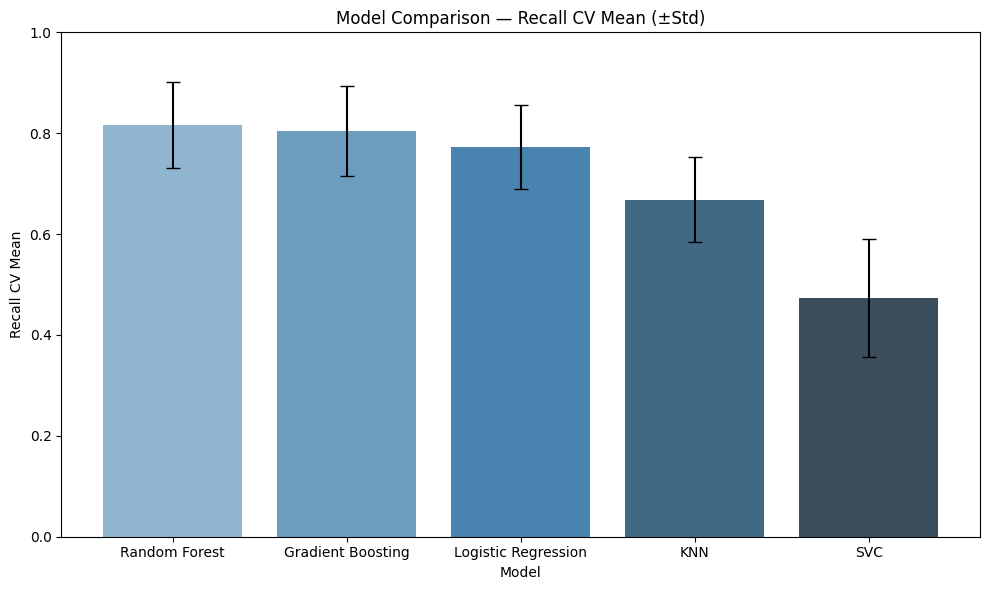

In [6]:
plot_df: pd.DataFrame = summary[[RECALL_SORT_COL, "recall_cv_std"]].reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=plot_df,
    x="Model",
    y=RECALL_SORT_COL,
    hue="Model",
    palette="Blues_d",
    ax=ax,
)
ax.errorbar(
    x=range(len(plot_df)),
    y=plot_df[RECALL_SORT_COL],
    yerr=plot_df["recall_cv_std"],
    fmt="none",
    color="black",
    capsize=5,
)
ax.set_title("Model Comparison — Recall CV Mean (±Std)")
ax.set_ylabel("Recall CV Mean")
ax.set_xlabel("Model")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 🧪 Test Set Evaluation

In [7]:
METRICS_LIST: list[str] = ["accuracy", "precision", "recall", "f1", "roc"]
result_dict: dict = {}

for name, model in models_to_test.items():
    # Create and fit pipeline
    pipeline: Pipeline = Pipeline(steps=[("preprocessor", create_preprocessor()), ("model", model)])
    pipeline.fit(X_train, y_train)

    # Predictions on train and test sets
    y_train_pred: np.ndarray = pipeline.predict(X_train)
    y_test_pred: np.ndarray = pipeline.predict(X_test)
    y_train_proba: np.ndarray = pipeline.predict_proba(X_train)[:, 1]
    y_test_proba: np.ndarray = pipeline.predict_proba(X_test)[:, 1]

    # Calculate metrics
    train_metrics: dict = {
        "accuracy": accuracy_score(y_train, y_train_pred),
        "precision": precision_score(y_train, y_train_pred, zero_division=0),
        "recall": recall_score(y_train, y_train_pred, zero_division=0),
        "f1": f1_score(y_train, y_train_pred, zero_division=0),
        "roc": roc_auc_score(y_train, y_train_proba),
    }

    test_metrics: dict = {
        "accuracy": accuracy_score(y_test, y_test_pred),
        "precision": precision_score(y_test, y_test_pred, zero_division=0),
        "recall": recall_score(y_test, y_test_pred, zero_division=0),
        "f1": f1_score(y_test, y_test_pred, zero_division=0),
        "roc": roc_auc_score(y_test, y_test_proba),
    }

    result_dict[name] = {"train": train_metrics, "test": test_metrics}

# Display results
for model_name, metrics in result_dict.items():
    print(f"\n{model_name}:")
    print(
        f"  Train - Accuracy: {metrics['train']['accuracy']:.4f} | Recall: {metrics['train']['recall']:.4f} | F1: {metrics['train']['f1']:.4f}"
    )
    print(
        f"  Test  - Accuracy: {metrics['test']['accuracy']:.4f} | Recall: {metrics['test']['recall']:.4f} | F1: {metrics['test']['f1']:.4f}"
    )


Logistic Regression:
  Train - Accuracy: 0.8203 | Recall: 0.7880 | F1: 0.8078
  Test  - Accuracy: 0.8125 | Recall: 0.8696 | F1: 0.8163

Random Forest:
  Train - Accuracy: 1.0000 | Recall: 1.0000 | F1: 1.0000
  Test  - Accuracy: 0.8333 | Recall: 0.8696 | F1: 0.8333

SVC:
  Train - Accuracy: 0.6562 | Recall: 0.4946 | F1: 0.5796
  Test  - Accuracy: 0.6250 | Recall: 0.3696 | F1: 0.4857

Gradient Boosting:
  Train - Accuracy: 0.9714 | Recall: 0.9565 | F1: 0.9697
  Test  - Accuracy: 0.8750 | Recall: 0.9348 | F1: 0.8776

KNN:
  Train - Accuracy: 0.7995 | Recall: 0.7935 | F1: 0.7913
  Test  - Accuracy: 0.7396 | Recall: 0.6739 | F1: 0.7126


### 📈 Train vs Test Metrics Comparison

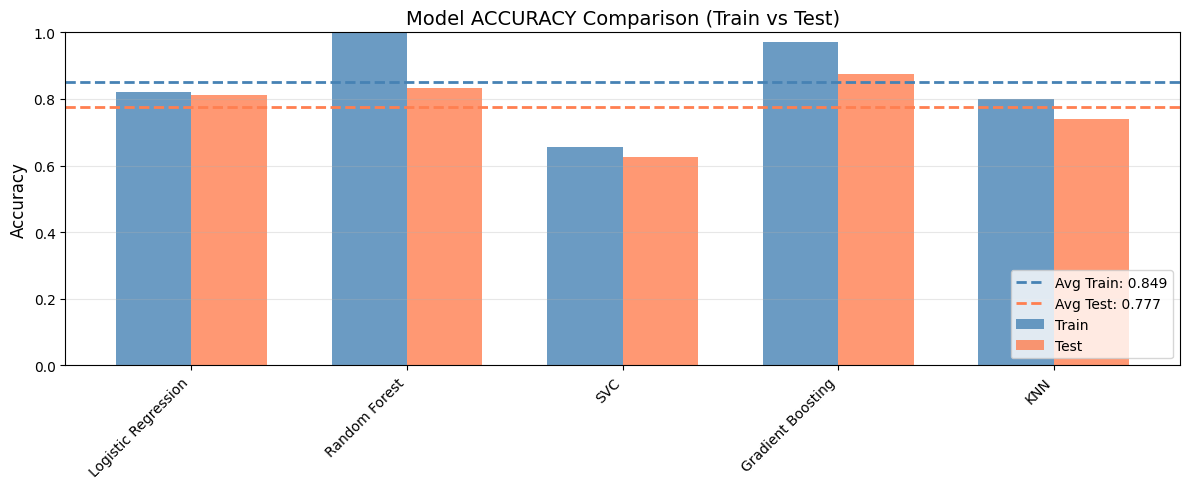

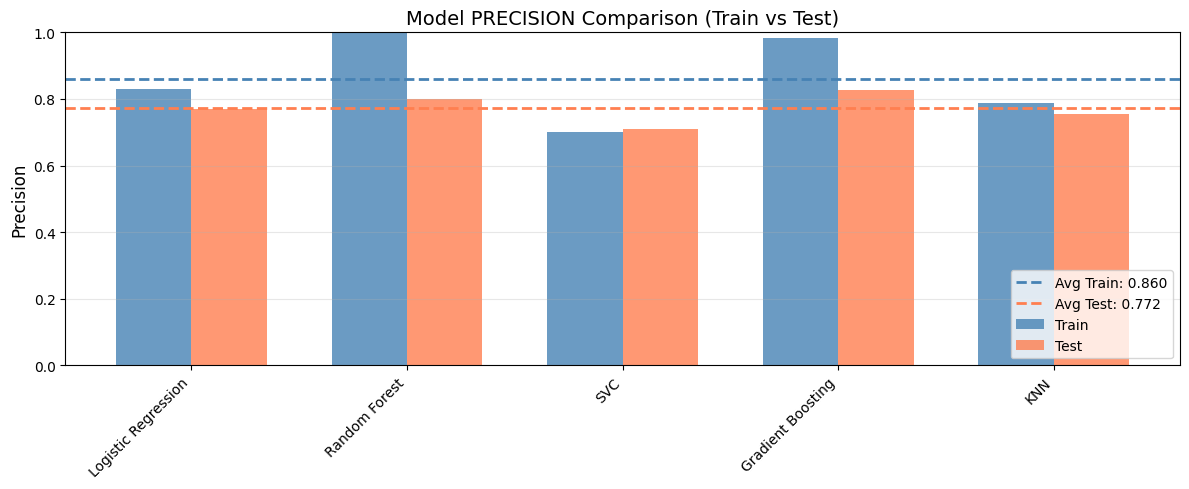

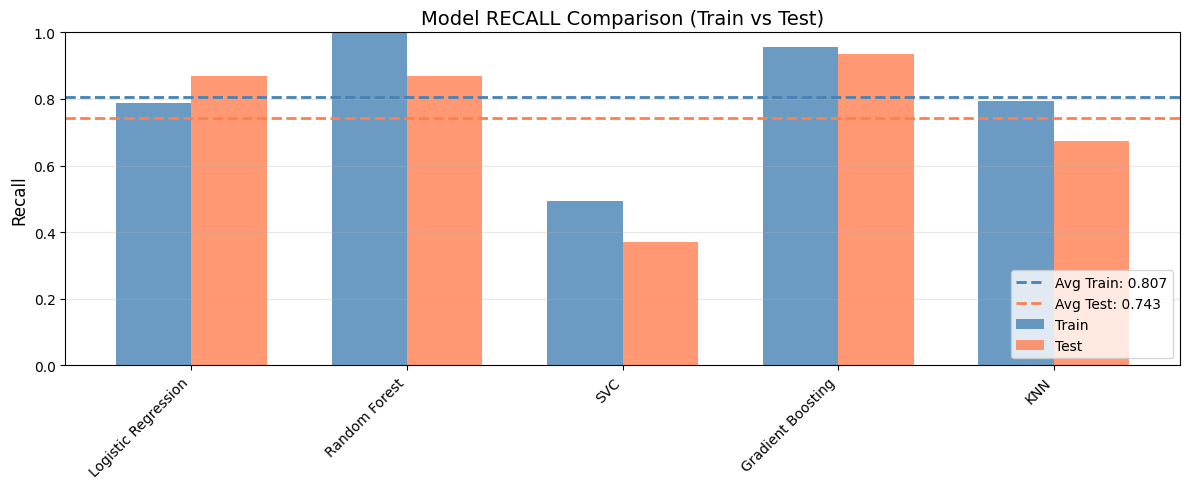

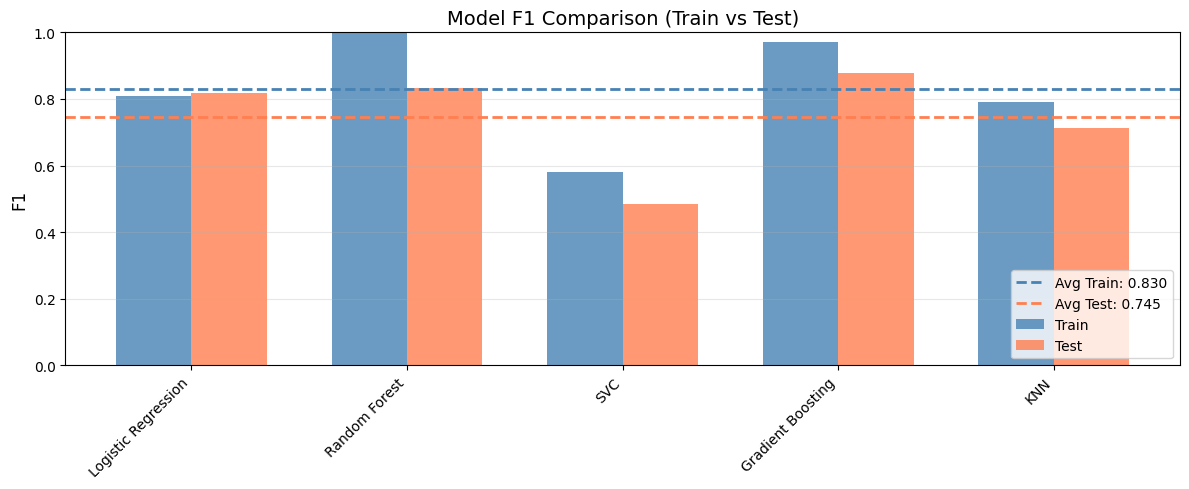

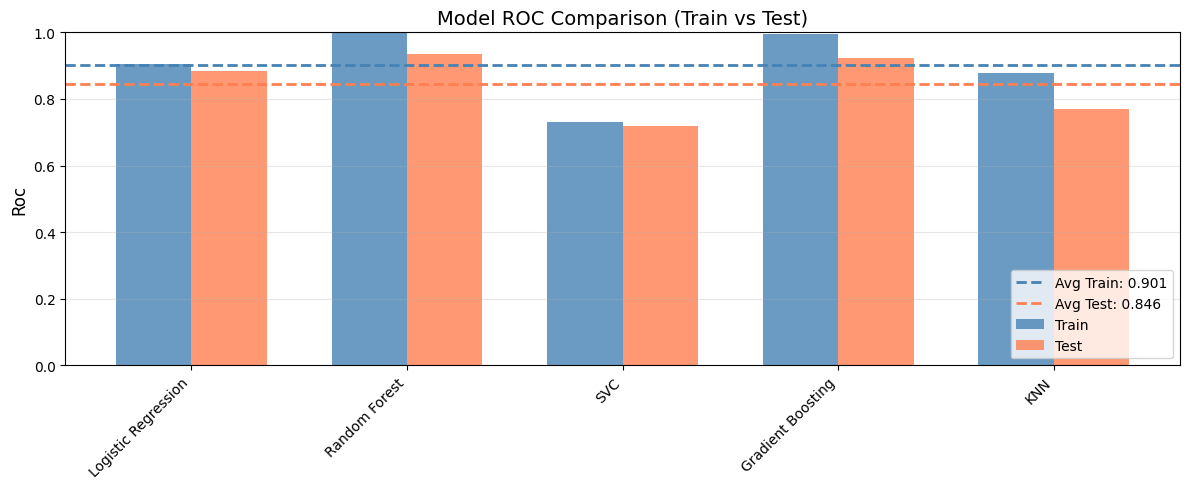

In [8]:
# Convert result_dict to DataFrames
data_train: dict = {
    metric: {model: result_dict[model]["train"][metric] for model in result_dict}
    for metric in METRICS_LIST
}
data_test: dict = {
    metric: {model: result_dict[model]["test"][metric] for model in result_dict}
    for metric in METRICS_LIST
}

df_train: pd.DataFrame = pd.DataFrame(data_train)
df_test: pd.DataFrame = pd.DataFrame(data_test)

# Plot bar charts for each metric
for metric in METRICS_LIST:
    fig, ax = plt.subplots(figsize=(12, 5))
    width: float = 0.35
    x: np.ndarray = np.arange(len(df_train.index))

    ax.bar(
        x - width / 2,
        df_train[metric],
        width,
        label="Train",
        color="steelblue",
        alpha=0.8,
    )
    ax.bar(x + width / 2, df_test[metric], width, label="Test", color="coral", alpha=0.8)

    # Add average lines
    avg_train: float = df_train[metric].mean()
    avg_test: float = df_test[metric].mean()
    ax.axhline(
        avg_train,
        color="steelblue",
        linestyle="--",
        linewidth=2,
        label=f"Avg Train: {avg_train:.3f}",
    )
    ax.axhline(
        avg_test,
        color="coral",
        linestyle="--",
        linewidth=2,
        label=f"Avg Test: {avg_test:.3f}",
    )

    ax.set_ylabel(metric.capitalize(), fontsize=12)
    ax.set_title(f"Model {metric.upper()} Comparison (Train vs Test)", fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(df_train.index, rotation=45, ha="right")
    ax.set_ylim(0, 1)
    ax.legend(loc="lower right")
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

### 🔍 Overfitting & Performance Analysis

In [9]:
# Create combined DataFrame with train/test differences
df_combined: pd.DataFrame = pd.concat(
    [df_train.add_suffix("_train"), df_test.add_suffix("_test")], axis=1
)

# Calculate differences (overfitting indicator)
for metric in METRICS_LIST:
    df_combined[f"{metric}_diff"] = df_combined[f"{metric}_train"] - df_combined[f"{metric}_test"]

# Detection thresholds
OVERFITTING_THRESHOLD: float = 0.1
SIMILAR_PERFORMANCE_THRESHOLD: float = 0.05

# Detect overfitting
overfitting_models: pd.DataFrame = df_combined[
    (df_combined["accuracy_diff"] > OVERFITTING_THRESHOLD)
    | (df_combined["precision_diff"] > OVERFITTING_THRESHOLD)
    | (df_combined["recall_diff"] > OVERFITTING_THRESHOLD)
    | (df_combined["f1_diff"] > OVERFITTING_THRESHOLD)
    | (df_combined["roc_diff"] > OVERFITTING_THRESHOLD)
]

# Calculate average performance
mean_performance_train: pd.Series = df_combined[[f"{m}_train" for m in METRICS_LIST]].mean()
mean_performance_test: pd.Series = df_combined[[f"{m}_test" for m in METRICS_LIST]].mean()

# Detect models with similar train/test performance (good generalization)
similar_performance_models: pd.DataFrame = df_combined[
    (df_combined["accuracy_diff"].abs() < SIMILAR_PERFORMANCE_THRESHOLD)
    & (df_combined["precision_diff"].abs() < SIMILAR_PERFORMANCE_THRESHOLD)
    & (df_combined["recall_diff"].abs() < SIMILAR_PERFORMANCE_THRESHOLD)
    & (df_combined["f1_diff"].abs() < SIMILAR_PERFORMANCE_THRESHOLD)
    & (df_combined["roc_diff"].abs() < SIMILAR_PERFORMANCE_THRESHOLD)
]

# Print analysis
print("=" * 70)
print("OVERFITTING ANALYSIS")
print("=" * 70)
print(f"\n✓ Models with overfitting (diff > {OVERFITTING_THRESHOLD}):")
if len(overfitting_models) > 0:
    for model in overfitting_models.index:
        print(f"  - {model}")
else:
    print("  None detected ✓")

print("\n✓ Models with similar train/test performance (generalization good):")
if len(similar_performance_models) > 0:
    for model in similar_performance_models.index:
        print(f"  - {model}")
else:
    print("  None detected")

# Show train-test differences
print("\n" + "=" * 70)
print("TRAIN-TEST DIFFERENCES (Train - Test)")
print("=" * 70)
diff_cols: list = [col for col in df_combined.columns if "_diff" in col]
print(df_combined[diff_cols].round(4))

OVERFITTING ANALYSIS

✓ Models with overfitting (diff > 0.1):
  - Random Forest
  - SVC
  - Gradient Boosting
  - KNN

✓ Models with similar train/test performance (generalization good):
  None detected

TRAIN-TEST DIFFERENCES (Train - Test)
                     accuracy_diff  precision_diff  recall_diff  f1_diff  \
Logistic Regression         0.0078          0.0593      -0.0815  -0.0085   
Random Forest               0.1667          0.2000       0.1304   0.1667   
SVC                         0.0312         -0.0083       0.1250   0.0939   
Gradient Boosting           0.0964          0.1563       0.0217   0.0921   
KNN                         0.0599          0.0331       0.1196   0.0787   

                     roc_diff  
Logistic Regression    0.0193  
Random Forest          0.0665  
SVC                    0.0125  
Gradient Boosting      0.0717  
KNN                    0.1061  
